# 05 — KNN Classifier

Trains and evaluates a K-Nearest Neighbors classifier across the three feature spaces built in notebook 03.

The vault split is **locked** and not touched here — it is reserved for final evaluation in notebook 08.

## Setup

In [7]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from config import TARGET_CLASSES, RANDOM_STATE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('../figures/05-KNN', exist_ok=True)

## Load Data

In [8]:
X_train      = joblib.load('../data/processed/X_train.pkl')
y_train      = joblib.load('../data/processed/y_train.pkl')
feature_sets = joblib.load('../data/processed/feature_sets.pkl')

print(f'Train : {X_train.shape}')
print(f'\nClass distribution (train):')
vc = pd.Series(y_train.values).value_counts().sort_index()
for idx, cnt in vc.items():
    print(f'  {idx} ({TARGET_CLASSES[idx]:<25}) — {cnt} samples')
print(f'\nFeature sets loaded: {list(feature_sets.keys())}')

Train : (1688, 11)

Class distribution (train):
  0 (Insufficient_Weight      ) — 218 samples
  1 (Normal_Weight            ) — 229 samples
  2 (Overweight_Level_I       ) — 232 samples
  3 (Overweight_Level_II      ) — 232 samples
  4 (Obesity_Type_I           ) — 281 samples
  5 (Obesity_Type_II          ) — 237 samples
  6 (Obesity_Type_III         ) — 259 samples

Feature sets loaded: ['original', 'pca', 'lasso']


## Class Balance Strategy

Unlike MLP or XGBoost, KNN does not support `sample_weight` in `.fit()`. Class imbalance will be addressed by setting `weights='distance'` in the KNN model, allowing closer neighbors to have a greater influence on the prediction.

## Cross-Validation Setup

**Hierarchical CV scheme:**
- 20% of the total dataset is held out as the **vault** — never loaded here
- All model selection happens via **5-fold stratified CV** on the remaining 80%
- Transformers are **re-fit inside each fold** on that fold's training portion only — prevents data leakage
- Sample weights are not used; class balance is handled via `weights='distance'`

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(X_raw, y, model, transformer=None, verbose=False):
    """
    5-fold stratified CV.

    Parameters
    ----------
    X_raw            : raw feature array (pre-transformation)
    y                : labels
    model            : sklearn-compatible classifier
    transformer      : optional transformer re-fit per fold to prevent leakage
    """
    y_arr = np.array(y)
    accs, f1s = [], []

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_raw, y_arr)):
        X_tr, X_val = X_raw[tr_idx], X_raw[val_idx]
        y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

        if transformer is not None:
            t = clone(transformer)
            X_tr  = t.fit_transform(X_tr, y_tr)
            X_val = t.transform(X_val)

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        if verbose:
            print(f'  Fold {fold+1}: acc={accs[-1]:.4f}  macro-F1={f1s[-1]:.4f}')

    return {
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'f1_mean' : np.mean(f1s),  'f1_std' : np.std(f1s),
    }

print('CV helper ready — StratifiedKFold(n_splits=5)')

CV helper ready — StratifiedKFold(n_splits=5)


## Models

### KNN Classifier
A non-parametric method that classifies based on the majority vote of its k nearest neighbors. `weights='distance'` gives higher influence to closer neighbors, helping with class imbalance.

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
)

## Run Cross-Validation

In [11]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

cv_transformers = {
    'original': None,
    'pca'     : PCA(n_components=0.95, random_state=RANDOM_STATE),
    'lasso'   : SelectFromModel(
                    LogisticRegression(solver='saga', l1_ratio=1, C=0.1,
                                       max_iter=2000, random_state=RANDOM_STATE,
                                       class_weight='balanced'),
                    threshold=1e-6
                ),
}

cv_results = {}

for fs_name, fs in feature_sets.items():
    print(f'\n── KNN on \'{fs_name}\' ({fs["n_features"]} features) ──')
    scores = cv_evaluate(
        X_train.values, y_train, knn,
        transformer=cv_transformers[fs_name],
        verbose=True
    )
    cv_results[fs_name] = scores
    print(f'  → Accuracy : {scores["acc_mean"]:.4f} ± {scores["acc_std"]:.4f}')
    print(f'  → Macro F1 : {scores["f1_mean"]:.4f} ± {scores["f1_std"]:.4f}')


── KNN on 'original' (11 features) ──
  Fold 1: acc=0.6923  macro-F1=0.6830
  Fold 2: acc=0.6331  macro-F1=0.6159
  Fold 3: acc=0.6065  macro-F1=0.5944
  Fold 4: acc=0.6409  macro-F1=0.6271
  Fold 5: acc=0.6855  macro-F1=0.6667
  → Accuracy : 0.6517 ± 0.0325
  → Macro F1 : 0.6374 ± 0.0327

── KNN on 'pca' (7 features) ──
  Fold 1: acc=0.6657  macro-F1=0.6557
  Fold 2: acc=0.6272  macro-F1=0.6112
  Fold 3: acc=0.6183  macro-F1=0.6107
  Fold 4: acc=0.6113  macro-F1=0.5952
  Fold 5: acc=0.6706  macro-F1=0.6530
  → Accuracy : 0.6386 ± 0.0247
  → Macro F1 : 0.6252 ± 0.0246

── KNN on 'lasso' (10 features) ──
  Fold 1: acc=0.6775  macro-F1=0.6661
  Fold 2: acc=0.6391  macro-F1=0.6239
  Fold 3: acc=0.6036  macro-F1=0.5927
  Fold 4: acc=0.6291  macro-F1=0.6158
  Fold 5: acc=0.6766  macro-F1=0.6569
  → Accuracy : 0.6452 ± 0.0285
  → Macro F1 : 0.6311 ± 0.0270


## Results Summary

In [12]:
summary_rows = []
for fs_name, scores in cv_results.items():
    summary_rows.append({
        'Model'       : 'KNN',
        'Feature Set' : fs_name,
        'N Features'  : feature_sets[fs_name]['n_features'],
        'CV Accuracy' : f"{scores['acc_mean']:.4f} ± {scores['acc_std']:.4f}",
        'CV Macro F1' : f"{scores['f1_mean']:.4f} ± {scores['f1_std']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Model Feature Set  N Features     CV Accuracy     CV Macro F1
  KNN    original          11 0.6517 ± 0.0325 0.6374 ± 0.0327
  KNN         pca           7 0.6386 ± 0.0247 0.6252 ± 0.0246
  KNN       lasso          10 0.6452 ± 0.0285 0.6311 ± 0.0270


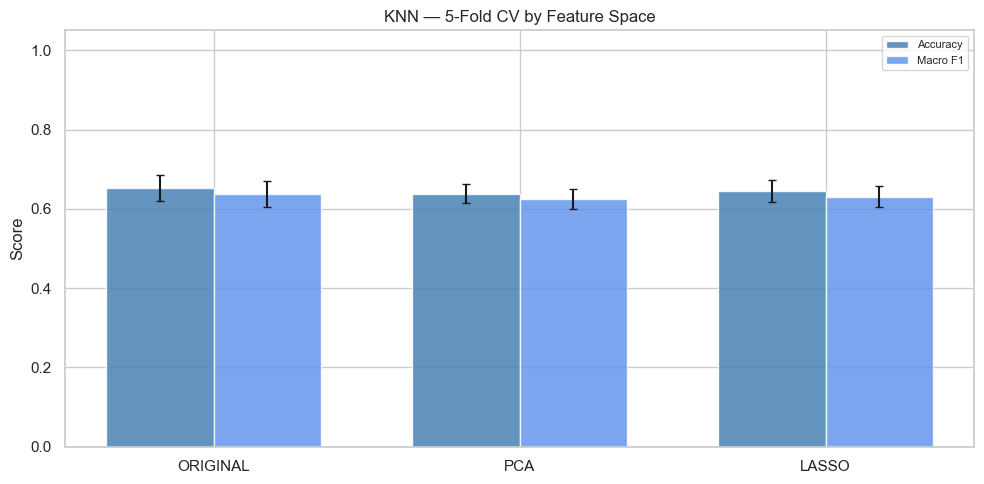

In [13]:
fs_labels = list(feature_sets.keys())
x     = np.arange(len(fs_labels))
width = 0.35
colors = ('steelblue', 'cornflowerblue')

fig, ax = plt.subplots(figsize=(10, 5))
bars_meta = [
    ('acc', -0.5 * width, colors[0], 'Accuracy'),
    ('f1',  0.5 * width, colors[1], 'Macro F1'),
]

for metric, offset, color, label in bars_meta:
    means = [cv_results[fs][f'{metric}_mean'] for fs in fs_labels]
    stds  = [cv_results[fs][f'{metric}_std']  for fs in fs_labels]
    ax.bar(x + offset, means, width, yerr=stds, capsize=3,
           label=label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f.upper() for f in fs_labels])
ax.set_ylabel('Score')
ax.set_title('KNN — 5-Fold CV by Feature Space')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/05-KNN/knn_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [14]:
joblib.dump(cv_results, '../data/processed/cv_results_knn.pkl')

# Re-train on full training set for use in notebook 08
trained_models = {}
for fs_name, fs in feature_sets.items():
    m = clone(knn)
    m.fit(fs['X_train'], y_train.values)
    trained_models[fs_name] = m
    print(f'Trained KNN ({fs_name})')

joblib.dump(trained_models, '../data/processed/trained_models_knn.pkl')
print('\nResults and models saved to data/processed/')

Trained KNN (original)
Trained KNN (pca)
Trained KNN (lasso)

Results and models saved to data/processed/


## Hyperparameter Tuning

Uses `RandomizedSearchCV` with the same 5-fold stratified CV to find better hyperparameters
for KNN on the 'original' feature space. Best parameters are selected on training folds only.

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

knn_param_dist = {
    'n_neighbors': randint(3, 50),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski'],
    'p'          : [1, 2],
}

print('Search space defined.')

Search space defined.


In [16]:
def tune_and_evaluate(X_raw, y, model, param_dist, transformer=None,
                      n_iter=30, verbose=False):
    """
    Runs RandomizedSearchCV to find best hyperparameters, then evaluates
    with 5-fold CV using those best parameters.
    """
    y_arr = np.array(y)

    # Find best params on full training set
    search = RandomizedSearchCV(
        estimator=clone(model),
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=CV,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    X_fit = X_raw
    if transformer is not None:
        t = clone(transformer)
        X_fit = t.fit_transform(X_raw, y_arr)

    search.fit(X_fit, y_arr)
    best_params = search.best_params_
    print(f'  Best params: {best_params}')

    # Evaluate best model with 5-fold CV
    best_model = clone(model).set_params(**best_params)
    accs, f1s = [], []

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_raw, y_arr)):
        X_tr, X_val = X_raw[tr_idx], X_raw[val_idx]
        y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

        if transformer is not None:
            t = clone(transformer)
            X_tr  = t.fit_transform(X_tr, y_tr)
            X_val = t.transform(X_val)

        m = clone(best_model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        if verbose:
            print(f'  Fold {fold+1}: acc={accs[-1]:.4f}  macro-F1={f1s[-1]:.4f}')

    return {
        'acc_mean'   : np.mean(accs), 'acc_std': np.std(accs),
        'f1_mean'    : np.mean(f1s),  'f1_std' : np.std(f1s),
        'best_params': best_params,
    }

print('Tuning helper ready.')

Tuning helper ready.


In [17]:
# This cell may take several minutes to run

cv_results_tuned = {}

for fs_name, fs in feature_sets.items():
    print(f'\n── KNN (tuned) on \'{fs_name}\' ({fs["n_features"]} features) ──')
    scores = tune_and_evaluate(
        X_train.values, y_train, knn, knn_param_dist,
        transformer=cv_transformers[fs_name],
        n_iter=30, verbose=True
    )
    cv_results_tuned[fs_name] = scores
    print(f'  → Accuracy : {scores["acc_mean"]:.4f} ± {scores["acc_std"]:.4f}')
    print(f'  → Macro F1 : {scores["f1_mean"]:.4f} ± {scores["f1_std"]:.4f}')


── KNN (tuned) on 'original' (11 features) ──
  Best params: {'metric': 'manhattan', 'n_neighbors': 8, 'p': 2, 'weights': 'distance'}
  Fold 1: acc=0.6864  macro-F1=0.6796
  Fold 2: acc=0.6627  macro-F1=0.6498
  Fold 3: acc=0.6391  macro-F1=0.6274
  Fold 4: acc=0.6617  macro-F1=0.6438
  Fold 5: acc=0.6766  macro-F1=0.6609
  → Accuracy : 0.6653 ± 0.0160
  → Macro F1 : 0.6523 ± 0.0174

── KNN (tuned) on 'pca' (7 features) ──
  Best params: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
  Fold 1: acc=0.6538  macro-F1=0.6430
  Fold 2: acc=0.6598  macro-F1=0.6451
  Fold 3: acc=0.6095  macro-F1=0.5964
  Fold 4: acc=0.6142  macro-F1=0.5915
  Fold 5: acc=0.6558  macro-F1=0.6340
  → Accuracy : 0.6386 ± 0.0220
  → Macro F1 : 0.6220 ± 0.0232

── KNN (tuned) on 'lasso' (10 features) ──
  Best params: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
  Fold 1: acc=0.6775  macro-F1=0.6717
  Fold 2: acc=0.6509  macro-F1=0.6363
  Fold 3: acc=0.6391  ma

In [18]:
# Tuned results summary
tuned_rows = []
for fs_name, scores in cv_results_tuned.items():
    tuned_rows.append({
        'Model'       : 'KNN (Tuned)',
        'Feature Set' : fs_name,
        'N Features'  : feature_sets[fs_name]['n_features'],
        'CV Accuracy' : f"{scores['acc_mean']:.4f} ± {scores['acc_std']:.4f}",
        'CV Macro F1' : f"{scores['f1_mean']:.4f} ± {scores['f1_std']:.4f}",
    })

tuned_df = pd.DataFrame(tuned_rows)
print('Tuned Results:')
print(tuned_df.to_string(index=False))

print('\nBest hyperparameters:')
for fs_name, scores in cv_results_tuned.items():
    print(f'  {fs_name}: {scores["best_params"]}')

Tuned Results:
      Model Feature Set  N Features     CV Accuracy     CV Macro F1
KNN (Tuned)    original          11 0.6653 ± 0.0160 0.6523 ± 0.0174
KNN (Tuned)         pca           7 0.6386 ± 0.0220 0.6220 ± 0.0232
KNN (Tuned)       lasso          10 0.6611 ± 0.0164 0.6500 ± 0.0162

Best hyperparameters:
  original: {'metric': 'manhattan', 'n_neighbors': 8, 'p': 2, 'weights': 'distance'}
  pca: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
  lasso: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}


## Save Final Results

In [19]:
joblib.dump(cv_results_tuned, '../data/processed/cv_results_knn_tuned.pkl')

# Re-train tuned models on full training set for use in notebook 08
trained_models_tuned = {}
for fs_name, fs in feature_sets.items():
    best_params = cv_results_tuned[fs_name]['best_params']
    m = clone(knn).set_params(**best_params)
    m.fit(fs['X_train'], y_train.values)
    trained_models_tuned[fs_name] = m
    print(f'Trained tuned KNN ({fs_name})')

joblib.dump(trained_models_tuned, '../data/processed/trained_models_knn_tuned.pkl')
print('\nTuned results and models saved to data/processed/')

Trained tuned KNN (original)
Trained tuned KNN (pca)
Trained tuned KNN (lasso)

Tuned results and models saved to data/processed/
